In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")



Usando dispositivo: cpu


## 1. Dataset

In [7]:
df = pd.read_csv("../data/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Exploración y preparación de los datos
### 2.1 Dimensiones del dataset

In [ ]:
print(f"Numero de observaciones: {df.shape[0]}")
print(f"Numero de variables: {df.shape[1]}")
df.info()

#### ¿Cuántas observaciones y cuántas variables tiene el dataset?

El dataset contiene 
- 20,640 observaciones (distritos censales de California)
- 10 variables (9 features + 1 variable objetivo).

### 2.2 Descripción de variables

### ¿Qué representa cada variable (feature) y cuál es la variable objetivo (target)?

| Variable | Descripción |
|---|---|
| longitude | Longitud geográfica del distrito |
| latitude | Latitud geográfica del distrito |
| housing_median_age | Edad mediana de las viviendas en el distrito (años) |
| total_rooms | Número total de habitaciones en el distrito |
| total_bedrooms | Número total de dormitorios en el distrito |
| population | Población total del distrito |
| households | Número total de hogares en el distrito |
| median_income | Ingreso mediano de los hogares del distrito (en decenas de miles de USD) |
| ocean_proximity | Categoría de proximidad al océano (categórica) |
| median_house_value | valor mediano de las viviendas del distrito (USD) |

### 2.3 Valores nulos, duplicados y atípicos


Valores nulos por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Filas duplicadas: 0
Valores nulos despues de imputacion: 0


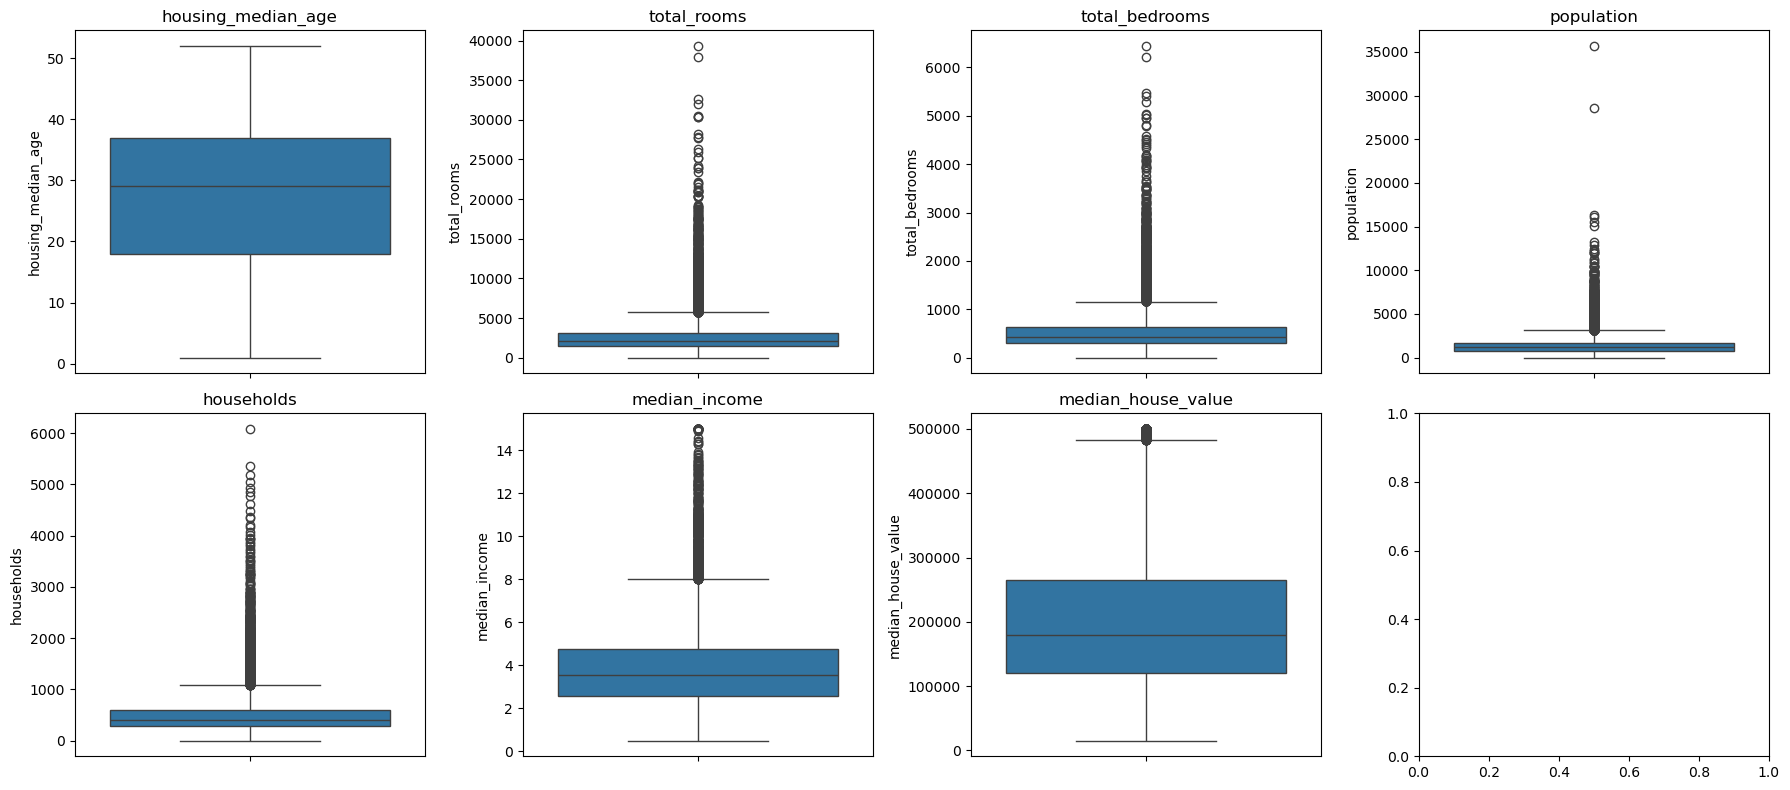

Valor maximo de median_house_value: 500001.0
Observaciones en el tope (500001): 965
Nuevo tamano del dataset: (19675, 10)


In [11]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
print("Valores nulos despues de imputacion:", df['total_bedrooms'].isnull().sum())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
num_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
            'households', 'median_income', 'median_house_value']
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Valor maximo de median_house_value:", df['median_house_value'].max())
print("Observaciones en el tope (500001):", (df['median_house_value'] == 500001).sum())

# Eliminamos observaciones con el valor "topado" (artefacto de recoleccion de datos)
df = df[df['median_house_value'] < 500001].reset_index(drop=True)
print("Nuevo tamano del dataset:", df.shape)

#### ¿Hay valores nulos, duplicados o atípicos (outliers)? ¿Cómo los trató?
La columna total_bedrooms tiene 207 valores nulos, los cuales se
imputaron con la mediana de la columna. No se encontraron filas duplicadas. Se identificaron valores
atipicos en varias variables (population, total_rooms, edian_income), y particularmente un
artefacto de recolección de datos en median_house_value, cual valor está "topado" en 500,001 USD para
todos los distritos con valores reales superiores. Estas observaciones se eliminaron para no chingar el
entrenamiento.



### 2.4 Variables numéricas vs categóricas

In [15]:
categorical_cols = ['ocean_proximity']
numeric_cols = [c for c in df.columns if c not in categorical_cols + ['median_house_value']]
print("Categoricas:", categorical_cols)
print("Numericas:", numeric_cols)
df['ocean_proximity'].value_counts()

df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)
df.head()

Categoricas: ['ocean_proximity']
Numericas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


#### ¿Qué variables son numéricas y cuáles categóricas? ¿Cómo codificó las categórica

La única variable categórica es ocean_proximity (5 categorias: <1H OCEAN,
INLAND, NEAR OCEAN, NEAR BAY, ISLAND).

Se codificó usando one-hot encoding (pd.get_dummies), ya que no existe una relación ordinal clara con categorias. El resto de
variables son numéricas continuas.

### 2.5 División del dataset y escalamiento

In [20]:
feature_cols = [c for c in df.columns if c != 'median_house_value']
X = df[feature_cols].values
y = df['median_house_value'].values.reshape(-1, 1)

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_val = scaler_y.transform(y_val)
y_test = scaler_y.transform(y_test)

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_train_t, y_train_t = to_tensor(X_train), to_tensor(y_train)
X_val_t, y_val_t = to_tensor(X_val), to_tensor(y_val)
X_test_t, y_test_t = to_tensor(X_test), to_tensor(y_test)

INPUT_DIM = X_train.shape[1]
print("Dimension de entrada:", INPUT_DIM)

Train: (13772, 13)  Val: (2951, 13)  Test: (2952, 13)
Dimension de entrada: 13


#### ¿Fue necesario normalizar o escalar las variables numéricas?

fue necesario escalar las variables numéricas ya que tienen rangos muy
distintos (population en miles vs median_income en decenas). Se usó StandardScale
(media 0, desviación estándar 1), ajustado unicamente con el conjunto de entrenamiento para evitar
data leakage.

## 3. Investigacion: capas y optimizadores de PyTorch
### 3.1 Capas de torch.nn

### nn.Linear(in_features, out_features, bias=True)
Es una capa totalmente conectada. Toma cada entrada y la combina con pesos y un sesgo (bias) para producir la salida. in_features es cuantos valores entran, out_features es cuantas neuronas tiene la capa. Es la capa basica de un MLP.

## Funciones de activacion

#### nn.ReLU():
- deja pasar los valores positivos igual y convierte los negativos en cero. Es rapida y funciona bien en la mayoria de los casos, aunque a veces algunas neuronas se "apagan" y dejan de aprender.
- 
#### nn.LeakyReLU(negative_slope=0.01):
- parecida a ReLU pero no apaga del todo los valores negativos, deja pasar una fraccion chiquita. Ayuda a evitar el problema de las neuronas apagadas (que da el RELU normal).
- 
#### nn.Tanh(): 
- convierte los valores a un rango entre -1 y 1. Esta centrada en cero, pero en redes muy profundas puede hacer que el gradiente se vuelva muy chiquitos.

#### nn.Dropout(p=0.5)
- En cada paso de entrenamiento apaga al azar un porcentaje p de las neuronas de la capa anterior. Esto evita que el modelo dependa demasiado de unas pocas neuronas y ayuda a que generalice mejor. Al evaluar el modelo "model.eval()" el dropout se desactiva solo.

#### nn.BatchNorm1d(num_features):
- Normaliza las salidas de una capa dentro de cada batch, dejandolas con media 0 y varianza 1, y despues aplica una transformacion ajustable. Ayuda a que el entrenamiento sea mas rapido y estable, y permite usar learning rates mas altos. num_features debe ser igual a la cantidad de neuronas de la capa que se normaliza.

## Funciones de perdida para regresion

#### nn.MSELoss():
- promedio del error al cuadrado. Castiga fuerte los errores grandes.
#### nn.L1Loss():
- promedio del error absoluto. Es mas resistente a valores atipicos que MSE.
#### nn.SmoothL1Loss():
- (Huber Loss): mezcla de las dos anteriores, se comporta como MSE para errores chicos y como L1 para errores grandes.

## 3.2 Optimizadores de torch.optim

#### SGD
- Actualiza los pesos dando pasos chiquitos en la dirección que reduce el error, usando el mismo tamaño de paso (learning rate) para todos los pesos. Es el método más simple y básico, pero también el más lento: necesita más épocas para converger y hay que ajustar bien el learning rate a mano, si no, puede aprender muy despacio o volverse inestable

#### Adam
- Es una versión mas "inteligente" de SGD: en vez de usar un solo tamaño de paso fijo, lo ajusta automáticamente para cada peso según cómo se ha ido comportando su gradiente. Gracias a esto aprende rapido y funciona bien casi sin necesidad de ajustar nada, por eso es el optimizador más usado hoy en día. La única desventaja es que a veces generaliza un poco peor que un SGD bien afinado.

#### RMSprop
- Funciona parecido a Adam: también ajusta el tamaño del paso para cada peso por separado, en vez de usar uno fijo para todos. Fue creado antes que Adam y pensado originalmente para redes recurrentes, y se puede ver como un antecesor directo de Adam.

## Sobre lr y weight_decay

#### lr (learning rate):
- define que tan grande es cada paso al actualizar los pesos. Si es muy alto el entrenamiento se puede volver inestable o divergir; si es muy bajo, el entrenamiento es lento o se queda atascado.
#### weight_decay:
- agrega una penalizacion (regularizacion L2) sobre el tamano de los pesos, para que no crezcan demasiado. Esto ayuda a reducir el overfitting.

## 4. Definición del modelo MLP

In [22]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_layers=[64, 32], activation='relu',
                 dropout=0.0, batch_norm=False):
        super().__init__()
        act_map = {'relu': nn.ReLU, 'leaky_relu': nn.LeakyReLU, 'tanh': nn.Tanh}
        act_fn = act_map[activation]

        layers = []
        in_dim = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(in_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def get_loss_fn(name):
    return {'mse': nn.MSELoss(), 'l1': nn.L1Loss(), 'smooth_l1': nn.SmoothL1Loss()}[name]

def get_optimizer(name, params, lr, weight_decay=0.0):
    if name == 'sgd':
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif name == 'adam':
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif name == 'rmsprop':
        return optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(name)

def train_model(config, X_train_t, y_train_t, X_val_t, y_val_t, verbose=False):
    torch.manual_seed(SEED)
    model = MLPRegressor(
        input_dim=INPUT_DIM,
        hidden_layers=config['hidden_layers'],
        activation=config['activation'],
        dropout=config.get('dropout', 0.0),
        batch_norm=config.get('batch_norm', False)
    ).to(device)

    loss_fn = get_loss_fn(config.get('loss', 'mse'))
    optimizer = get_optimizer(config['optimizer'], model.parameters(),
                               config['lr'], config.get('weight_decay', 0.0))

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                               batch_size=config['batch_size'], shuffle=True)

    l1_lambda = config.get('l1_lambda', 0.0)
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(config['epochs']):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t.to(device))
            val_loss = loss_fn(val_preds, y_val_t.to(device)).item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if verbose and (epoch % 10 == 0 or epoch == config['epochs'] - 1):
            print(f"Epoch {epoch+1}/{config['epochs']} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

    return model, history

def evaluate(model, X_t, y_t, scaler_y):
    model.eval()
    with torch.no_grad():
        preds = model(X_t.to(device)).cpu().numpy()
    preds_inv = scaler_y.inverse_transform(preds)
    y_inv = scaler_y.inverse_transform(y_t.numpy())

    mse = mean_squared_error(y_inv, preds_inv)
    mae = mean_absolute_error(y_inv, preds_inv)
    rmse = np.sqrt(mse)
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse}

## 5. Iteración de hiperparámetros (12 configuraciones)

In [26]:
configs = [
    {'name': 'Iter 1',  'hidden_layers': [64, 32],      'activation': 'relu',       'optimizer': 'adam',    'lr': 0.001,  'batch_size': 32,  'epochs': 50, 'weight_decay': 0.0,   'dropout': 0.0, 'batch_norm': False},
    {'name': 'Iter 2',  'hidden_layers': [128, 64, 32], 'activation': 'relu',       'optimizer': 'adam',    'lr': 0.001,  'batch_size': 32,  'epochs': 50, 'weight_decay': 0.0,   'dropout': 0.0, 'batch_norm': False},
    {'name': 'Iter 3',  'hidden_layers': [64, 32],      'activation': 'leaky_relu', 'optimizer': 'adam',    'lr': 0.001,  'batch_size': 32,  'epochs': 50, 'weight_decay': 0.0,   'dropout': 0.0, 'batch_norm': False},
    {'name': 'Iter 4',  'hidden_layers': [64, 32],      'activation': 'tanh',       'optimizer': 'adam',    'lr': 0.001,  'batch_size': 32,  'epochs': 50, 'weight_decay': 0.0,   'dropout': 0.0, 'batch_norm': False},
    {'name': 'Iter 5',  'hidden_layers': [64, 32],      'activation': 'relu',       'optimizer': 'sgd',     'lr': 0.01,   'batch_size': 32,  'epochs': 50, 'weight_decay': 0.0,   'dropout': 0.0, 'batch_norm': False},
    {'name': 'Iter 6',  'hidden_layers': [64, 32],      'activation': 'relu',       'optimizer': 'rmsprop', 'lr': 0.001,  'batch_size': 32,  'epochs': 50, 'weight_decay': 0.0,   'dropout': 0.0, 'batch_norm': False},
    {'name': 'Iter 7',  'hidden_layers': [64, 32],      'activation': 'relu',       'optimizer': 'adam',    'lr': 0.0005, 'batch_size': 64,  'epochs': 50, 'weight_decay': 0.0,   'dropout': 0.0, 'batch_norm': False},
    {'name': 'Iter 8',  'hidden_layers': [64, 32],      'activation': 'relu',       'optimizer': 'adam',    'lr': 0.001,  'batch_size': 32,  'epochs': 50, 'weight_decay': 1e-4,  'dropout': 0.0, 'batch_norm': False},
    {'name': 'Iter 9',  'hidden_layers': [64, 32],      'activation': 'relu',       'optimizer': 'adam',    'lr': 0.001,  'batch_size': 32,  'epochs': 50, 'weight_decay': 0.0,   'dropout': 0.3, 'batch_norm': False},
    {'name': 'Iter 10', 'hidden_layers': [64, 32],      'activation': 'relu',       'optimizer': 'adam',    'lr': 0.001,  'batch_size': 32,  'epochs': 50, 'weight_decay': 1e-4,  'dropout': 0.3, 'batch_norm': True},
    {'name': 'Iter 11', 'hidden_layers': [128, 64],     'activation': 'relu',       'optimizer': 'adam',    'lr': 0.001,  'batch_size': 128, 'epochs': 80, 'weight_decay': 1e-4,  'dropout': 0.2, 'batch_norm': True},
    {'name': 'Iter 12', 'hidden_layers': [32],          'activation': 'relu',       'optimizer': 'adam',    'lr': 0.001,  'batch_size': 32,  'epochs': 50, 'weight_decay': 0.0,   'dropout': 0.0, 'batch_norm': False},
]

print(f"Total de configuraciones a evaluar: {len(configs)}")

Total de configuraciones a evaluar: 12


In [33]:
results = []
histories = {}
trained_models = {}

for cfg in configs:
    print(f"Entrenando {cfg['name']}...")
    model, history = train_model(cfg, X_train_t, y_train_t, X_val_t, y_val_t, verbose=False)
    metrics = evaluate(model, X_val_t, y_val_t, scaler_y)

    results.append({
        'Iteracion': cfg['name'],
        'Arquitectura': cfg['hidden_layers'],
        'Activacion': cfg['activation'],
        'Optimizador': cfg['optimizer'],
        'LR': cfg['lr'],
        'Batch': cfg['batch_size'],
        'Epochs': cfg['epochs'],
        'Weight Decay': cfg['weight_decay'],
        'Dropout': cfg['dropout'],
        'BatchNorm': cfg['batch_norm'],
        'MSE (val)': metrics['MSE'],
        'MAE (val)': metrics['MAE'],
        'RMSE (val)': metrics['RMSE'],
    })

    histories[cfg['name']] = history
    trained_models[cfg['name']] = model

results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values('RMSE (val)').reset_index(drop=True)
results_df_sorted

iters_to_plot = ['Iter 1', 'Iter 9', 'Iter 10']  # baseline, dropout, mejor configuracion


Entrenando Iter 1...
Entrenando Iter 2...
Entrenando Iter 3...
Entrenando Iter 4...
Entrenando Iter 5...
Entrenando Iter 6...
Entrenando Iter 7...
Entrenando Iter 8...
Entrenando Iter 9...
Entrenando Iter 10...
Entrenando Iter 11...
Entrenando Iter 12...


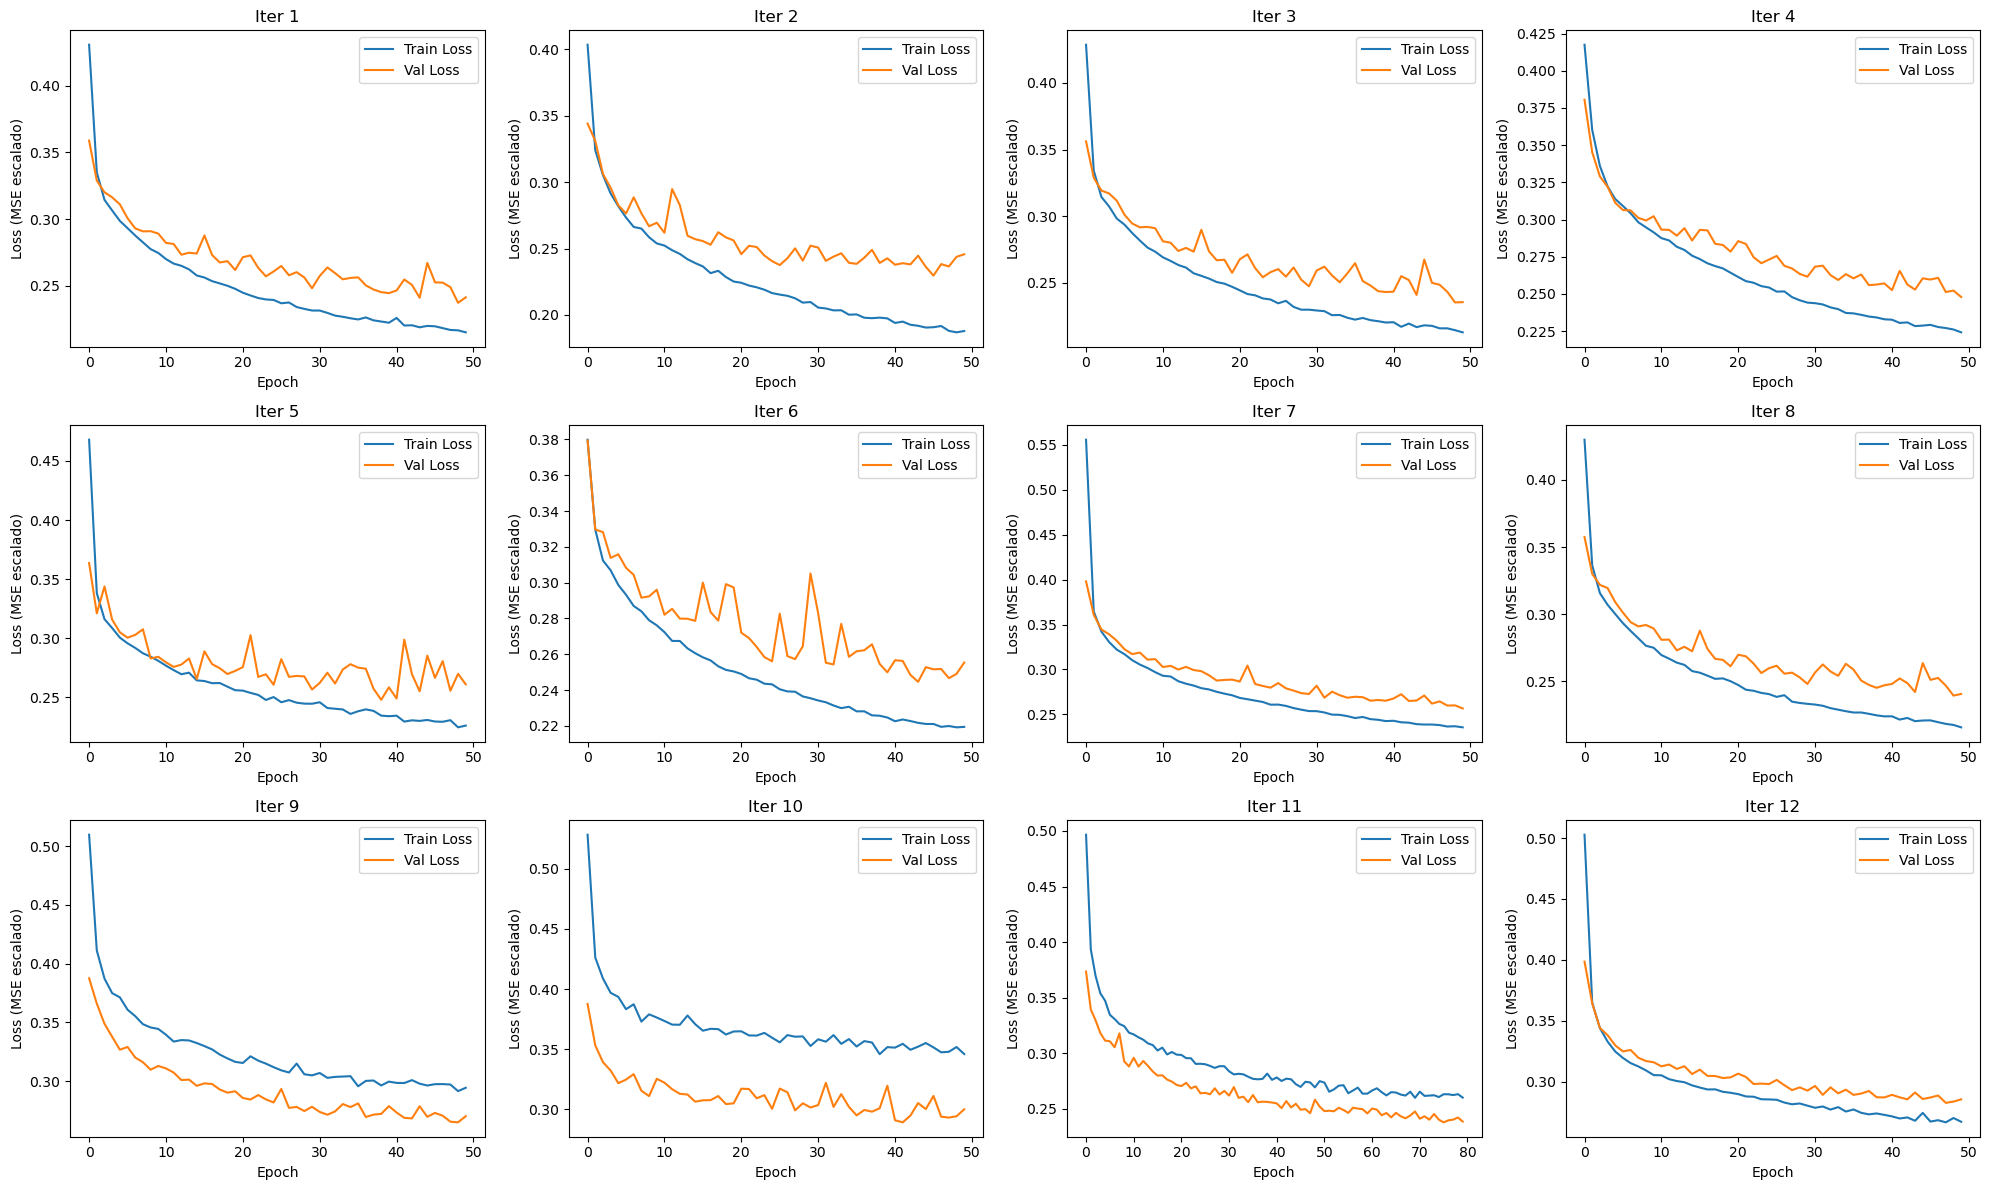

In [35]:
iters_to_plot = [cfg['name'] for cfg in configs]  # todas las iteraciones

n_cols = 4
n_rows = int(np.ceil(len(iters_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, it in zip(axes, iters_to_plot):
    h = histories[it]
    ax.plot(h['train_loss'], label='Train Loss')
    ax.plot(h['val_loss'], label='Val Loss')
    ax.set_title(it)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE escalado)')
    ax.legend()

# Ocultar ejes sobrantes si el numero de iteraciones no llena la grilla
for ax in axes[len(iters_to_plot):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Agarrando el mejor modelo

In [30]:
best_iter_name = results_df_sorted.iloc[0]['Iteracion']
best_model = trained_models[best_iter_name]
print(f"Mejor configuracion segun RMSE de validacion: {best_iter_name}")

test_metrics = evaluate(best_model, X_test_t, y_test_t, scaler_y)
print("Metricas finales sobre el conjunto de TEST:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.2f}")

Mejor configuracion segun RMSE de validacion: Iter 3
Metricas finales sobre el conjunto de TEST:
  MSE: 2369783552.00
  MAE: 33858.18
  RMSE: 48680.42


## 7. Discusión y análisis (según los resultados obtenidos)

### ¿Qué cambio tuvo el mayor impacto positivo/negativo?
El mayor impacto positivo lo dio cambiar la activación a LeakyReLU con Adam (Iter 3), que terminó siendo la mejor configuración con RMSE de validación más bajo. El mayor impacto negativo se ve en Iter 5 y 6 (SGD y RMSprop): sus curvas de pérdida se quedan en valores más altos (0.45–0.55) y más ruidosas que las demás, mostrando que les cuesta más converger con esos hiperparámetros.

### ¿Observó overfitting o underfitting?
Sí. En casi todas las iteraciones la curva de validación queda por encima de la de entrenamiento y es bastante más ruidosa (sube y baja mucho), lo cual es una señal de overfitting leve: el modelo aprende mejor los datos de entrenamiento que los de validación. Iter 6 (RMSprop) es el caso más marcado, con picos grandes en la pérdida de validación. Esto se mitigó parcialmente en las iteraciones con dropout y batch norm (Iter 9, 10, 11), donde la curva de validación se ve un poco más estable.

### ¿La regularización mejoro el desempeño?
Ayudó a que las curvas fueran más estables, pero en este caso la mejor configuración final (Iter 3) no fue la que más regularización tenía, sino la que ajustó la activación y el optimizador. Esto sugiere que en este dataset la arquitectura y el optimizador pesan más que la regularización.

### Batch size y epochs
Las iteraciones con batch más pequeño (32) muestran curvas de validación más ruidosas, pero convergen rápido. Iter 11, con batch 128 y más epochs, tiene una curva más suave, lo que confirma que batches grandes dan entrenamientos más estables pero necesitan más epochs para llegar a resultados parecidos.

### MSE, MAE y RMSE
Con el modelo final (Iter 3) se obtuvo MSE ≈ 2,369,783,552, MAE es maso menos 33,858 y RMSE maso menos 48,680. Como RMSE es más alto que MAE, quiere decir que hay algunos distritos donde el modelo se equivoca bastante más que en el resto (errores grandes puntuales), mientras que el error "tipico" (MAE) es más moderado.

### Modelo de producción recomendado
Con base en los resultados, usaría la configuración de Iter 3 (LeakyReLU + Adam, lr 0.001) como punto de partida, y seguiría optimizando con una búsqueda bayesiana (por ejemplo con Optuna) para ajustar mejor el batch size y la regularización sin tener que probar manualmente cada combinación.

## 8. Conclusiones (simple)
- El mejor modelo fue Iter 3, con RMSE de test de aproximadamente $48,680.
- Casi todas las iteraciones mostraron un poco de overfitting: la validación es más ruidosa que el entrenamiento.
- SGD y RMSprop (Iter 5 y 6) tardaron más en aprender que Adam.
- La regularización ayudó a estabilizar el entrenamiento, pero no fue el factor que más mejoró el resultado final.
- El modelo se evaluó una sola vez en test, como se pidió, para tener una medida justa de su desempeño real.